# 使用SC cell_type标记Stage1聚类结果

本 notebook 根据单细胞(SC) h5ad 文件中的 `cell_type` 注解，标记第一阶段聚类得到的每个 cluster 所属的细胞类型。

In [1]:
# 1. 导入必要的库
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# 设置显示参数
sc.set_figure_params(figsize=(8, 8), dpi=80)
sns.set_style("whitegrid")
print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. 加载SC和ST数据

指定 SC、ST 的 h5ad 文件路径以及 stage1 的聚类结果文件路径。

In [2]:
# 设置文件路径
sample_name = "CID44971"
stage1_output_dir = "./stage1_results/CID44971/cluster"
sc_clustered_file = f"{stage1_output_dir}/sc_adata_clustered.h5ad"

print(f"Loading: {sc_clustered_file}")

# 加载已经有 cluster 和 celltype 的数据
sc_adata = sc.read_h5ad(sc_clustered_file)
print(f"✓ Loaded SC: {sc_adata.shape}")
print(f"  Columns: {sc_adata.obs.columns.tolist()}")
print()

Loading: ./stage1_results/CID44971/cluster/sc_adata_clustered.h5ad
✓ Loaded SC: (7740, 17323)
  Columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'cell_type', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'modality', 'leiden']



## 3. 提取cell_type信息并验证

In [3]:
# 获取 cluster 和 celltype 信息
clusters = sorted(sc_adata.obs['leiden'].unique())
cell_types = sc_adata.obs['cell_type'].unique()

print(f"Clusters: {len(clusters)} → {clusters}")
print(f"Cell types: {len(cell_types)} → {list(cell_types)}")
print()

# 统计每个 cluster 的 celltype 分布
cluster_to_celltype = {}
cluster_celltype_dist = {}

print("Cluster-CellType Mapping:")
print("="*60)

for cluster_id in clusters:
    cluster_mask = sc_adata.obs['leiden'] == cluster_id
    celltype_counts = sc_adata.obs[cluster_mask]['cell_type'].value_counts()
    
    # 多数投票
    major_celltype = celltype_counts.index[0]
    major_count = celltype_counts.iloc[0]
    total = cluster_mask.sum()
    pct = major_count / total * 100
    
    cluster_to_celltype[cluster_id] = major_celltype
    cluster_celltype_dist[cluster_id] = celltype_counts.to_dict()
    
    print(f"  Cluster {cluster_id}: {major_celltype:20s} ({major_count}/{total}, {pct:.1f}%)")

print("="*60)


Clusters: 20 → ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
Cell types: 9 → ['Endothelial', 'CAFs', 'PVL', 'B-cells', 'Plasmablasts', 'T-cells', 'Myeloid', 'Cancer Epithelial', 'Normal Epithelial']

Cluster-CellType Mapping:
  Cluster 0: T-cells              (1557/1557, 100.0%)
  Cluster 1: T-cells              (1036/1037, 99.9%)
  Cluster 10: Endothelial          (209/209, 100.0%)
  Cluster 11: Normal Epithelial    (165/166, 99.4%)
  Cluster 12: T-cells              (122/122, 100.0%)
  Cluster 13: T-cells              (86/87, 98.9%)
  Cluster 14: Normal Epithelial    (85/85, 100.0%)
  Cluster 15: PVL                  (84/84, 100.0%)
  Cluster 16: Myeloid              (72/72, 100.0%)
  Cluster 17: T-cells              (58/58, 100.0%)
  Cluster 18: Plasmablasts         (40/41, 97.6%)
  Cluster 19: Normal Epithelial    (37/37, 100.0%)
  Cluster 2: Cancer Epithelial    (779/788, 98.9%)
  Cluster 3: T-cells              (705

## 4. 映射Cluster到Cell Type

根据 stage1 聚类结果，统计每个 cluster 中的 cell_type 分布，使用多数投票（majority voting）将主要 cell_type 分配给每个 cluster。

In [8]:
# 生成映射表
mapping_df = pd.DataFrame({
    'Cluster': list(cluster_to_celltype.keys()),
    'CellType': list(cluster_to_celltype.values())
})

print("Cluster → CellType Mapping:")
print(mapping_df.to_string(index=False))
print()

# 生成详细分布表
detailed_rows = []
for cluster_id in clusters:
    for celltype, count in cluster_celltype_dist[cluster_id].items():
        detailed_rows.append({
            'Cluster': cluster_id,
            'CellType': celltype,
            'Count': count
        })


Cluster → CellType Mapping:
Cluster          CellType
      0           T-cells
      1           T-cells
     10       Endothelial
     11 Normal Epithelial
     12           T-cells
     13           T-cells
     14 Normal Epithelial
     15               PVL
     16           Myeloid
     17           T-cells
     18      Plasmablasts
     19 Normal Epithelial
      2 Cancer Epithelial
      3           T-cells
      4              CAFs
      5           Myeloid
      6           T-cells
      7 Normal Epithelial
      8           B-cells
      9           T-cells



## 6. UMAP可视化

计算 UMAP...


/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 17323 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


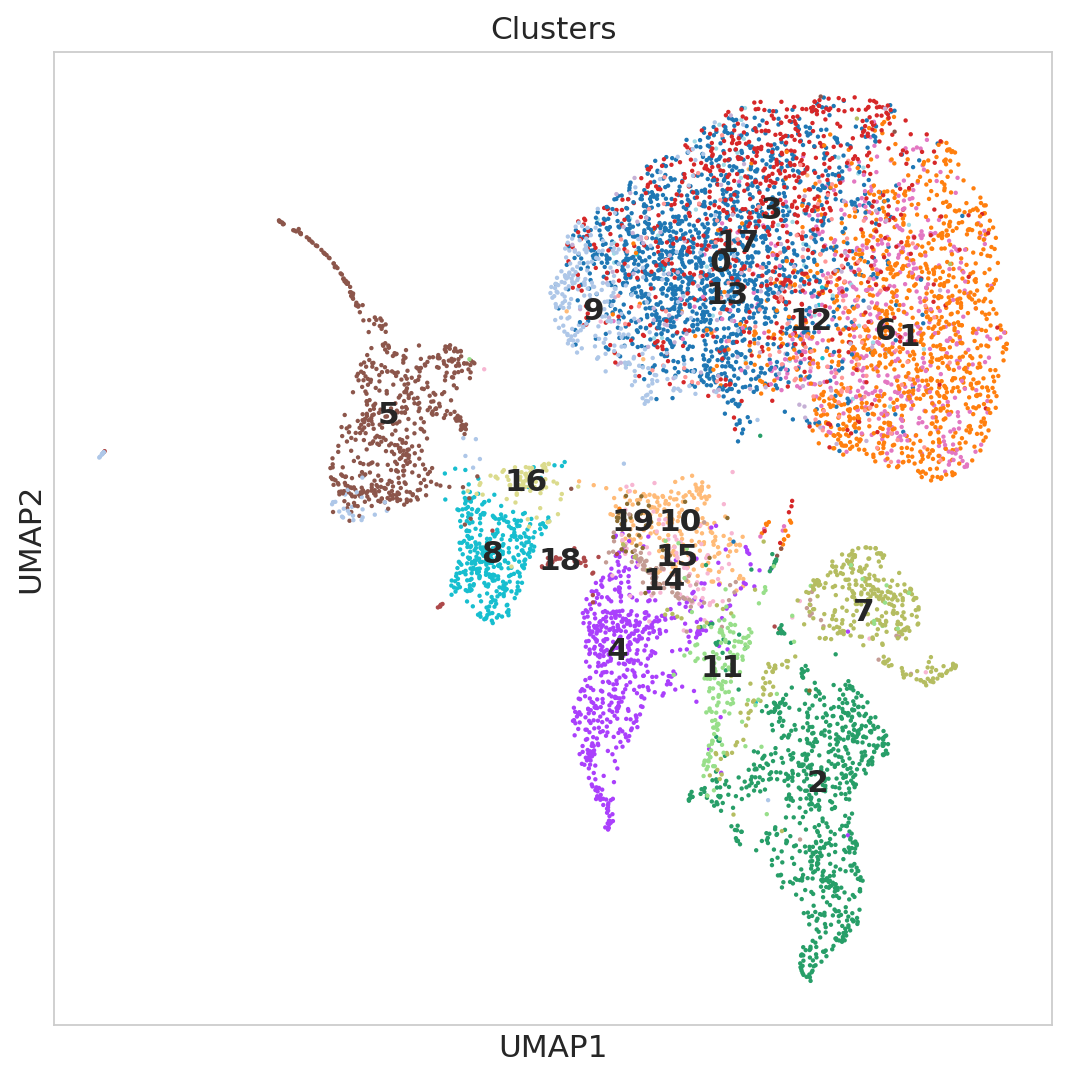

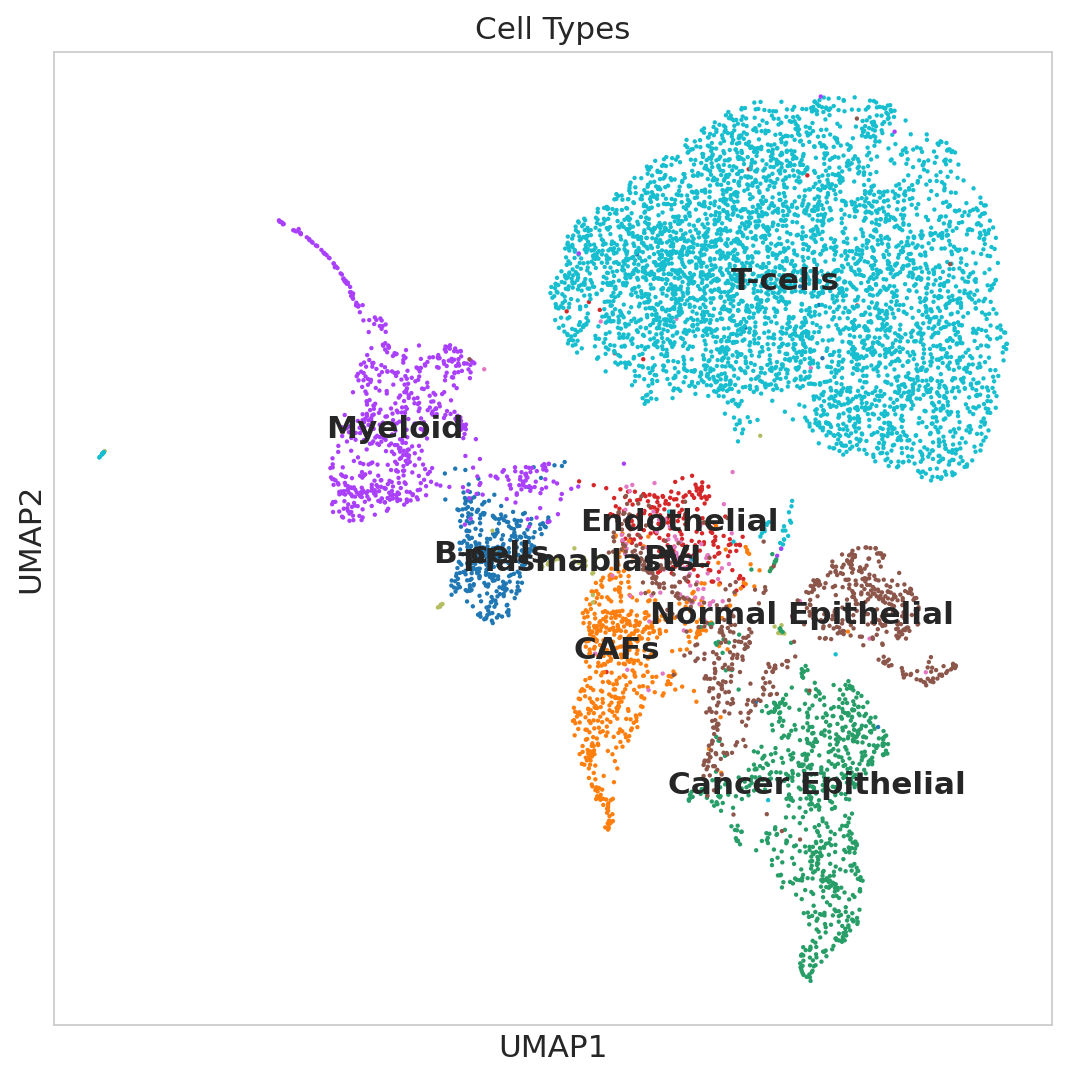

In [6]:
# UMAP 可视化
if 'X_umap' not in sc_adata.obsm:
    print("计算 UMAP...")
    sc.pp.neighbors(sc_adata, n_neighbors=10, n_pcs=20)
    sc.tl.umap(sc_adata)

# 按 cluster 着色
sc.pl.umap(sc_adata, color='leiden', legend_loc='on data', title='Clusters', show=True)

# 按 celltype 着色
sc.pl.umap(sc_adata, color='cell_type', legend_loc='on data', title='Cell Types', show=True)


## 7. 保存标记结果

将映射关系和标记后的数据保存到文件中，以便后续使用。

In [7]:
# 保存结果
import json
import os

output_dir = stage1_output_dir
os.makedirs(output_dir, exist_ok=True)

# 保存映射表
mapping_df.to_csv(f"{output_dir}/cluster_celltype_mapping.csv", index=False)
detailed_df.to_csv(f"{output_dir}/cluster_celltype_distribution.csv", index=False)

# 保存为 JSON
with open(f"{output_dir}/cluster_celltype_mapping.json", 'w') as f:
    json.dump({str(k): v for k, v in cluster_to_celltype.items()}, f, indent=2)

print("✓ 结果已保存到:")
print(f"  - {output_dir}/cluster_celltype_mapping.csv")
print(f"  - {output_dir}/cluster_celltype_distribution.csv")
print(f"  - {output_dir}/cluster_celltype_mapping.json")


✓ 结果已保存到:
  - ./stage1_results/CID44971/cluster/cluster_celltype_mapping.csv
  - ./stage1_results/CID44971/cluster/cluster_celltype_distribution.csv
  - ./stage1_results/CID44971/cluster/cluster_celltype_mapping.json


## 完成！

已生成 cluster 到 celltype 的映射表，保存在 stage1 输出目录中。